# 13. Hfq は自分の翻訳を抑える — 負の自己制御による恒常性

> **出典**: Morita T, Aiba H (2019) *Mechanism and physiological significance of autoregulation of the Escherichia coli hfq gene.* RNA 25(2):264-276.

Hfq タンパク質は自分の mRNA の 5'-UTR（distal 面）に結合して、自分の翻訳を止める（**負の自己制御**）。
論文の実験では、hfq mRNA を **~3倍**過剰発現しても Hfq タンパク質は **~1.4倍**しか増えず頭打ちになる。
生理的意義: 過剰 Hfq は rim を介して無関係な RNA を巻き込んで毒性を出すので、**一定範囲に保つ**必要がある。

## 負フィードバックの最小モデル（Hfq が自分の mRNA を隔離＝翻訳沈黙化）

| 反応 | 意味 |
|---|---|
| $\varnothing\to m$ | hfq 転写 $\alpha$（プラスミド/IPTG で可変） |
| $m\to\varnothing$ | mRNA 分解 $\beta_m$ |
| $m\to m+p$ | 翻訳（**自由な** mRNA からのみ） |
| $p\to\varnothing$ | Hfq 希釈 $\beta_p$ |
| $m+p\rightleftharpoons mp$ | Hfq が自分の mRNA に結合→翻訳沈黙（auto のみ） |
| $mp\to p$ | 沈黙 mRNA も分解し Hfq を放出 |

負フィードバックの**2大効果**を見る: (1) **恒常性**（転写を上げても Hfq 量が緩衝される）、(2) **応答が速い**。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

M, P, MP = (Species(x) for x in ['m','p','mp'])
B_M, K_TL, B_P, K_B, K_U = 0.3, 2.0, 0.05, 0.4, 0.1
SP = ['m','p','mp']
def R(a,b,k): return ReactionRule(a,b,k)

def build(alpha, auto):
    rules = [R([],[M],alpha), R([M],[],B_M), R([M],[M,P],K_TL), R([P],[],B_P)]
    if auto:
        rules += [R([M,P],[MP],K_B), R([MP],[M,P],K_U), R([MP],[P],B_M)]
    mdl = NetworkModel()
    for r in rules: mdl.add_reaction_rule(r)
    return mdl

def steady(alpha, auto):
    v = dict(zip(SP, run_simulation(600., y0={}, model=build(alpha,auto), solver='ode', ndiv=1, species_list=SP).as_array()[-1][1:]))
    return v['m']+v['mp'], v['p']+v['mp']
def timecourse(alpha, auto, t_end=50.0, ndiv=2000):
    a = run_simulation(t_end, y0={}, model=build(alpha,auto), solver='ode', ndiv=ndiv, species_list=SP).as_array()
    return a[:,0], a[:,2]+a[:,3]
print('ready')

ready


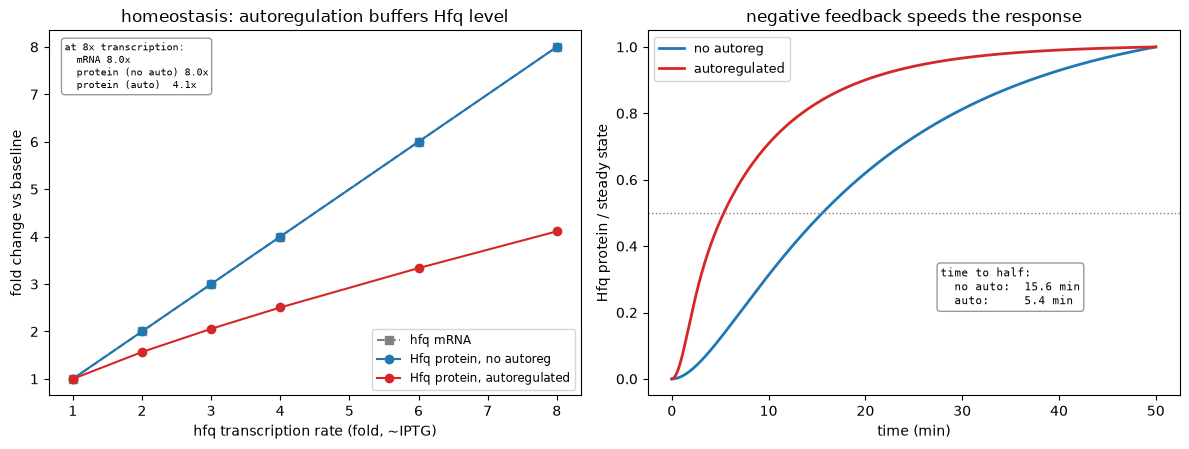

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

a_grid = np.array([1,2,3,4,6,8], dtype=float)
m0a, p0a = steady(1, True); m0n, p0n = steady(1, False)
m_fold = [steady(a, True)[0]/m0a for a in a_grid]
p_auto = [steady(a, True)[1]/p0a for a in a_grid]
p_noauto = [steady(a, False)[1]/p0n for a in a_grid]
ax1.plot(a_grid, m_fold, 's--', color='gray', label='hfq mRNA')
ax1.plot(a_grid, p_noauto, 'o-', color='C0', label='Hfq protein, no autoreg')
ax1.plot(a_grid, p_auto, 'o-', color='C3', label='Hfq protein, autoregulated')
ax1.set_xlabel('hfq transcription rate (fold, ~IPTG)'); ax1.set_ylabel('fold change vs baseline')
ax1.set_title('homeostasis: autoregulation buffers Hfq level'); ax1.legend(fontsize=8.5)
ax1.text(0.03,0.97, f'at 8x transcription:\n  mRNA {m_fold[-1]:.1f}x\n'
         f'  protein (no auto) {p_noauto[-1]:.1f}x\n  protein (auto)  {p_auto[-1]:.1f}x',
         transform=ax1.transAxes, fontsize=7.5, va='top', family='monospace',
         bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=.8))

ht = {}
for auto, c, lab in [(False,'C0','no autoreg'), (True,'C3','autoregulated')]:
    t, p = timecourse(1.0, auto); y = p/p[-1]
    ax2.plot(t, y, '-', color=c, lw=2, label=lab)
    ht[auto] = t[np.where(y >= 0.5)[0][0]]
ax2.axhline(0.5, ls=':', c='gray', lw=1)
ax2.set_xlabel('time (min)'); ax2.set_ylabel('Hfq protein / steady state')
ax2.set_title('negative feedback speeds the response'); ax2.legend(fontsize=9)
ax2.text(0.55,0.25, f'time to half:\n  no auto:  {ht[False]:.1f} min\n  auto:     {ht[True]:.1f} min',
         transform=ax2.transAxes, fontsize=8, family='monospace',
         bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=.8))
plt.tight_layout(); plt.show()

## 読み取り

- **左（恒常性）**: 転写 $\alpha$ を 8倍にすると hfq mRNA も 8倍になるが、**自己制御ありの Hfq タンパク質は ~4倍で頭打ち**。
  自己制御なしなら 8倍まで素直に増える。Hfq が自分の mRNA を沈黙化することで、**過剰発現を打ち消して量を一定範囲に保つ**
  ——論文 Fig.1B（mRNA 3倍でもタンパク質 1.4倍）と同じ向きの緩衝。
- **右（速さ）**: 負フィードバックは定常への到達を速める。半到達時間は ~16分 → ~5分。刺激に対して素早く落ち着く
  （Rosenfeld/Alon の古典的結果）。

> **注**: 本モデルは 1:1 の自己隔離で、緩衝は理論上限 ~$\sqrt{\ }$ 程度（8倍→~3倍）。実際の hfq 自己制御は
> もっと厳密（3倍→1.4倍）で、これは Hfq 六量体の**協同的**な結合や翻訳阻害の非線形性が効くため。方向と機構は同じ。

**02〜12 との関係**: これまで Hfq は「与えられた資源」だった。13 は **Hfq 量そのものがどう決まるか**（自分で自分を抑える）を扱う。
この恒常性があるからこそ、06〜12 で見た Hfq 依存の制御が安定して働ける。

## 発展課題（自作）

1. 協同結合（$m+2p\to mp$）に変えると、緩衝は強まるか（論文の厳密さに近づくか）を試す。
2. 外乱応答: 定常状態から転写 $\alpha$ を急に2倍にしたとき、auto と no-auto で Hfq の行き過ぎ（overshoot）や整定時間を比べる。
3. この自己制御を 08 の競合モデルに組み込み、Hfq が恒常化されると競合の影響がどう変わるか見る。
4. [[bio-a_hfq-phylogenetics]]: 自己制御は 5'-UTR と distal 面の相互作用に依存する。UTR や distal 面残基の系統差を、
   「自己制御の強さ＝Hfq 量の安定性」の違いとして解釈してみる。